In [2]:
import pandas as pd
import glob
import os

files = glob.glob("../data/external/ki_endolist/ki-dataset/User*.csv")

print("Patients:", len(files))

Patients: 34


In [3]:
dfs = []

for file in files:
    df = pd.read_csv(file)
    dfs.append(df)

all_data = pd.concat(dfs)

print(all_data.shape)

(5112, 387)


In [4]:
all_data.info()

<class 'pandas.DataFrame'>
Index: 5112 entries, 0 to 121
Columns: 387 entries, User id to Burning / numbness / sore feet (0-no pain, 10-worst pain)
dtypes: float64(383), int64(3), str(1)
memory usage: 15.1 MB


In [5]:
all_data.describe()

,User id,Day in study,Cycle number,Cycle day,First day of period,"Period (0-no, 1-yes)","Migraines (0-no pain, 4-worst pain)","Period pain (0-no pain, 4-worst pain)","Type of stool (0-no stool, 7-bowel blockage)","General emotional condition (1-bad, 10-amazing)",...,"Groin burning sensation (0-no burning, 10-worst burning)","Muscle tightness (0-no tightness, 10-worst tightness)","Urgency urination (0-no urgency, 10-worst urgency)","Rib pain R (0-no pain, 10-worst pain)","Uterine cramps (0-no cramps, 10-worst cramps)","Pain radiating to the buttock (0-no pain, 10-worst pain)","Vaginal dryness / itching (0-no pain, 10-worst pain)","Stabbing pain in ovaries (0-no pain, 10-worst pain)","Neck muscles cramps L (0-no pain, 10-worst pain)","Burning / numbness / sore feet (0-no pain, 10-worst pain)"
count,5112.000000,5112.000000,4791.000000,5112.000000,4672.000000,4576.000000,670.000000,1641.000000,3133.000000,3334.000000,...,108.000000,107.000000,107.000000,107.000000,105.000000,108.000000,108.00000,105.000000,106.000000,109.000000
mean,59.482003,99.780516,3.774577,15.393584,0.042166,0.217002,0.283582,0.452773,3.368337,6.475705,...,0.055556,2.364486,1.439252,1.280374,0.104762,0.194444,1.12963,0.476190,1.584906,1.522936
std,14.479574,75.473990,2.468869,9.572736,0.200989,0.412249,0.731646,0.878118,1.750291,1.537367,...,0.330203,1.469132,1.304402,1.071011,0.414260,0.571248,1.29768,0.785631,1.136979,1.584627
min,38.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,48.000000,39.750000,2.000000,7.000000,0.000000,0.000000,0.000000,0.000000,2.000000,6.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000
50%,61.000000,83.000000,3.000000,15.000000,0.000000,0.000000,0.000000,0.000000,4.000000,7.000000,...,0.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.00000,0.000000,1.000000,1.000000
75%,71.000000,144.000000,5.000000,22.000000,0.000000,0.000000,0.000000,1.000000,5.000000,7.000000,...,0.000000,3.000000,2.000000,2.000000,0.000000,0.000000,2.00000,1.000000,2.000000,2.000000
max,87.000000,355.000000,12.000000,54.000000,1.000000,1.000000,4.000000,4.000000,7.000000,10.000000,...,3.000000,8.000000,6.000000,6.000000,2.000000,3.000000,5.00000,3.000000,5.000000,7.000000


In [6]:
missing = all_data.isnull().mean() * 100

missing.sort_values(ascending=False).head(30)

Working from home (0-no, 1-yes)                                                                             99.980438
Acamol focus (times)                                                                                        99.960876
Abitren suppository (times)                                                                                 99.941315
Esracain cream (times)                                                                                      99.921753
Burning sensation after intercourse (0-no pain, 4-worst pain)                                               99.902191
Lower abdominal cramps (0-no pain, 4-worst pain)                                                            99.902191
Voltaren injection (times)                                                                                  99.882629
Voltaren cream (times)                                                                                      99.863067
Abitren injection (times)                               

In [7]:
all_data.columns.tolist()

['User id',
 'Day in study',
 'Week day',
 'Cycle number',
 'Cycle day',
 'First day of period',
 'Period (0-no, 1-yes)',
 'Migraines (0-no pain, 4-worst pain)',
 'Period pain (0-no pain, 4-worst pain)',
 'Type of stool (0-no stool, 7-bowel blockage)',
 'General emotional condition (1-bad, 10-amazing)',
 'General physical condition (1-bad, 10-amazing)',
 'Breast tenderness (0-no pain, 4-worst pain)',
 'Energy (0-no energy, 4-most energy)',
 'Painful bowel movement (0-no pain, 4-worst pain)',
 'Desire to eat sweet food (0-no appetite, 4-most appetite)',
 'Lower back pain and pelvic pain (0-no pain, 4-worst pain)',
 'Lower abdominal stabbing pain / abdominal cramps (0-no pain, 4-worst pain)',
 'Ovulation pain (0-no pain, 4-worst pain)',
 'Paracetamol (times)',
 'Ovulation test values (0.0-4.0)',
 'Knee pain (0-no pain, 4-worst pain)',
 'Pain in ankle (0-no pain, 4-worst pain)',
 'Sick day (0-no, 1-yes)',
 'Naxyn (times)',
 'Appetite (0-no appetite, 4-most appetite)',
 'Headache (0-no pai

In [9]:
cols = pd.DataFrame({
    "Column": all_data.columns
})

cols.to_csv(
    "../docs/ki_endolist_columns.csv",
    index=False
)

In [10]:
missing.sort_values(ascending=False).head(30)

Working from home (0-no, 1-yes)                                                                             99.980438
Acamol focus (times)                                                                                        99.960876
Abitren suppository (times)                                                                                 99.941315
Esracain cream (times)                                                                                      99.921753
Burning sensation after intercourse (0-no pain, 4-worst pain)                                               99.902191
Lower abdominal cramps (0-no pain, 4-worst pain)                                                            99.902191
Voltaren injection (times)                                                                                  99.882629
Voltaren cream (times)                                                                                      99.863067
Abitren injection (times)                               

In [11]:
missing = all_data.isnull().mean() * 100

good_cols = missing[missing < 30]

print("Usable Columns:", len(good_cols))
print(good_cols.sort_values().head(100))

Usable Columns: 7
User id                  0.000000
Day in study             0.000000
Week day                 0.000000
Cycle day                0.000000
Cycle number             6.279343
First day of period      8.607199
Period (0-no, 1-yes)    10.485133
dtype: float64


In [12]:
all_data.count().sort_values(ascending=False).head(50)

User id                                                      5112
Cycle day                                                    5112
Week day                                                     5112
Day in study                                                 5112
Cycle number                                                 4791
First day of period                                          4672
Period (0-no, 1-yes)                                         4576
Bleeding (0-no bleeding, 4-heaviest bleeding)                3386
General physical condition (1-bad, 10-amazing)               3337
General emotional condition (1-bad, 10-amazing)              3334
Type of stool (0-no stool, 7-bowel blockage)                 3133
Lower back pain (0-no pain, 4-worst pain)                    2075
Ovulation test values (0.0-4.0)                              1889
Headache (0-no pain, 4-worst pain)                           1879
Appetite / no appetite (0-no appetite, 10-most appetite)     1811
Nausea (0-

In [14]:
usable = all_data.count()

top_features = usable[usable > 1000]

print(top_features)

User id                                                      5112
Day in study                                                 5112
Week day                                                     5112
Cycle number                                                 4791
Cycle day                                                    5112
First day of period                                          4672
Period (0-no, 1-yes)                                         4576
Period pain (0-no pain, 4-worst pain)                        1641
Type of stool (0-no stool, 7-bowel blockage)                 3133
General emotional condition (1-bad, 10-amazing)              3334
General physical condition (1-bad, 10-amazing)               3337
Breast tenderness (0-no pain, 4-worst pain)                  1401
Painful bowel movement (0-no pain, 4-worst pain)             1465
Desire to eat sweet food (0-no appetite, 4-most appetite)    1332
Ovulation test values (0.0-4.0)                              1889
Sick day (

In [15]:
usable = all_data.count()

symptoms = usable[
    (usable > 1000) &
    (~usable.index.str.contains("User id")) &
    (~usable.index.str.contains("Day in study")) &
    (~usable.index.str.contains("Week day"))
]

print(symptoms)

Cycle number                                                 4791
Cycle day                                                    5112
First day of period                                          4672
Period (0-no, 1-yes)                                         4576
Period pain (0-no pain, 4-worst pain)                        1641
Type of stool (0-no stool, 7-bowel blockage)                 3133
General emotional condition (1-bad, 10-amazing)              3334
General physical condition (1-bad, 10-amazing)               3337
Breast tenderness (0-no pain, 4-worst pain)                  1401
Painful bowel movement (0-no pain, 4-worst pain)             1465
Desire to eat sweet food (0-no appetite, 4-most appetite)    1332
Ovulation test values (0.0-4.0)                              1889
Sick day (0-no, 1-yes)                                       1506
Endo belly (0-no endo belly , 4-worst endo belly)            1285
Lower back pain (0-no pain, 4-worst pain)                    2075
Medical ca

In [16]:
selected_cols = [
    "Cycle number",
    "Cycle day",
    "First day of period",
    "Period (0-no, 1-yes)",
    "Ovulation test values (0.0-4.0)",
    "Bleeding (0-no bleeding, 4-heaviest bleeding)",
    "Period pain (0-no pain, 10-worst pain)",
    "Lower back pain (0-no pain, 4-worst pain)",
    "Abdominal cramps (0-no pain, 4-worst pain)",
    "Right pelvic pain (0-no pain, 4-worst pain)",
    "Ovaries pain (0-no pain, 4-worst pain)",
    "Painful bowel movement (0-no pain, 4-worst pain)",
    "Pain before bowel movement (0-no pain, 4-worst pain)",
    "Headache (0-no pain, 4-worst pain)",
    "Bloating (0-no bloating, 4-worst bloating)",
    "Nausea (0-no nausea, 4-worst nausea)",
    "Type of stool (0-no stool, 7-bowel blockage)",
    "Multiple bowel movement (0, 3 -more than 6)",
    "Appetite / no appetite (0-no appetite, 10-most appetite)",
    "Desire to eat sweet food (0-no appetite, 4-most appetite)",
    "General emotional condition (1-bad, 10-amazing)",
    "General physical condition (1-bad, 10-amazing)",
    "Fatigue (0-no fatigue, 10-worst fatigue)",
    "Insomnia (0-no insomnia, 4-worst insomnia)",
    "Acne (0-no acne, 4-worst acne)",
    "High / low libido (0-no libido, 10-high libido)",
    "Sick day (0-no, 1-yes)"
]

df_v2 = all_data[selected_cols]

print(df_v2.shape)
print(df_v2.isnull().mean().sort_values(ascending=False))

(5112, 27)
Insomnia (0-no insomnia, 4-worst insomnia)                   0.802426
High / low libido (0-no libido, 10-high libido)              0.799100
Fatigue (0-no fatigue, 10-worst fatigue)                     0.786385
Period pain (0-no pain, 10-worst pain)                       0.777582
Multiple bowel movement (0, 3 -more than 6)                  0.772496
Pain before bowel movement (0-no pain, 4-worst pain)         0.748044
Acne (0-no acne, 4-worst acne)                               0.746479
Ovaries pain (0-no pain, 4-worst pain)                       0.742371
Right pelvic pain (0-no pain, 4-worst pain)                  0.740023
Desire to eat sweet food (0-no appetite, 4-most appetite)    0.739437
Bloating (0-no bloating, 4-worst bloating)                   0.724765
Painful bowel movement (0-no pain, 4-worst pain)             0.713419
Sick day (0-no, 1-yes)                                       0.705399
Abdominal cramps (0-no pain, 4-worst pain)                   0.674687
Nausea (0

In [17]:
print(df_v2.isnull().mean().sort_values(ascending=False))

Insomnia (0-no insomnia, 4-worst insomnia)                   0.802426
High / low libido (0-no libido, 10-high libido)              0.799100
Fatigue (0-no fatigue, 10-worst fatigue)                     0.786385
Period pain (0-no pain, 10-worst pain)                       0.777582
Multiple bowel movement (0, 3 -more than 6)                  0.772496
Pain before bowel movement (0-no pain, 4-worst pain)         0.748044
Acne (0-no acne, 4-worst acne)                               0.746479
Ovaries pain (0-no pain, 4-worst pain)                       0.742371
Right pelvic pain (0-no pain, 4-worst pain)                  0.740023
Desire to eat sweet food (0-no appetite, 4-most appetite)    0.739437
Bloating (0-no bloating, 4-worst bloating)                   0.724765
Painful bowel movement (0-no pain, 4-worst pain)             0.713419
Sick day (0-no, 1-yes)                                       0.705399
Abdominal cramps (0-no pain, 4-worst pain)                   0.674687
Nausea (0-no nausea,

In [18]:
missing_pct = (
    df_v2.isnull().mean() * 100
).sort_values(ascending=False)

print(missing_pct)

Insomnia (0-no insomnia, 4-worst insomnia)                   80.242567
High / low libido (0-no libido, 10-high libido)              79.910016
Fatigue (0-no fatigue, 10-worst fatigue)                     78.638498
Period pain (0-no pain, 10-worst pain)                       77.758216
Multiple bowel movement (0, 3 -more than 6)                  77.249609
Pain before bowel movement (0-no pain, 4-worst pain)         74.804382
Acne (0-no acne, 4-worst acne)                               74.647887
Ovaries pain (0-no pain, 4-worst pain)                       74.237089
Right pelvic pain (0-no pain, 4-worst pain)                  74.002347
Desire to eat sweet food (0-no appetite, 4-most appetite)    73.943662
Bloating (0-no bloating, 4-worst bloating)                   72.476526
Painful bowel movement (0-no pain, 4-worst pain)             71.341941
Sick day (0-no, 1-yes)                                       70.539906
Abdominal cramps (0-no pain, 4-worst pain)                   67.468701
Nausea

In [19]:
core_cols = [
    "Cycle day",
    "Period (0-no, 1-yes)",
    "Bleeding (0-no bleeding, 4-heaviest bleeding)",
    "General emotional condition (1-bad, 10-amazing)",
    "General physical condition (1-bad, 10-amazing)",
    "Type of stool (0-no stool, 7-bowel blockage)"
]

df_core = df_v2[core_cols]

print(df_core.dropna().shape)

(1478, 6)


In [20]:
pain_cols = [
    "Cycle day",
    "Period (0-no, 1-yes)",
    "Period pain (0-no pain, 10-worst pain)",
    "Lower back pain (0-no pain, 4-worst pain)",
    "Abdominal cramps (0-no pain, 4-worst pain)"
]

print(df_v2[pain_cols].dropna().shape)

(0, 5)


In [21]:
symptoms = [
    "Period pain (0-no pain, 10-worst pain)",
    "Lower back pain (0-no pain, 4-worst pain)",
    "Abdominal cramps (0-no pain, 4-worst pain)",
    "Headache (0-no pain, 4-worst pain)",
    "Nausea (0-no nausea, 4-worst nausea)"
]

for col in symptoms:
    print(col)
    print(df_v2[col].notna().sum())
    print()

Period pain (0-no pain, 10-worst pain)
1137

Lower back pain (0-no pain, 4-worst pain)
2075

Abdominal cramps (0-no pain, 4-worst pain)
1663

Headache (0-no pain, 4-worst pain)
1879

Nausea (0-no nausea, 4-worst nausea)
1681



In [22]:
df_core.describe()

,Cycle day,"Period (0-no, 1-yes)","Bleeding (0-no bleeding, 4-heaviest bleeding)","General emotional condition (1-bad, 10-amazing)","General physical condition (1-bad, 10-amazing)","Type of stool (0-no stool, 7-bowel blockage)"
count,5112.000000,4576.000000,3386.000000,3334.000000,3337.000000,3133.000000
mean,15.393584,0.217002,0.497637,6.475705,6.186395,3.368337
std,9.572736,0.412249,0.974184,1.537367,1.711513,1.750291
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,0.000000,0.000000,6.000000,5.000000,2.000000
50%,15.000000,0.000000,0.000000,7.000000,6.000000,4.000000
75%,22.000000,0.000000,1.000000,7.000000,7.000000,5.000000
max,54.000000,1.000000,4.000000,10.000000,10.000000,7.000000


In [23]:
df_core.corr(numeric_only=True)

,Cycle day,"Period (0-no, 1-yes)","Bleeding (0-no bleeding, 4-heaviest bleeding)","General emotional condition (1-bad, 10-amazing)","General physical condition (1-bad, 10-amazing)","Type of stool (0-no stool, 7-bowel blockage)"
Cycle day,1.000000,-0.626253,-0.542801,0.017378,0.044637,-0.015729
"Period (0-no, 1-yes)",-0.626253,1.000000,0.811250,-0.129591,-0.202936,0.039019
"Bleeding (0-no bleeding, 4-heaviest bleeding)",-0.542801,0.811250,1.000000,-0.208607,-0.284580,0.027625
"General emotional condition (1-bad, 10-amazing)",0.017378,-0.129591,-0.208607,1.000000,0.621255,0.003450
"General physical condition (1-bad, 10-amazing)",0.044637,-0.202936,-0.284580,0.621255,1.000000,-0.055207
"Type of stool (0-no stool, 7-bowel blockage)",-0.015729,0.039019,0.027625,0.003450,-0.055207,1.000000


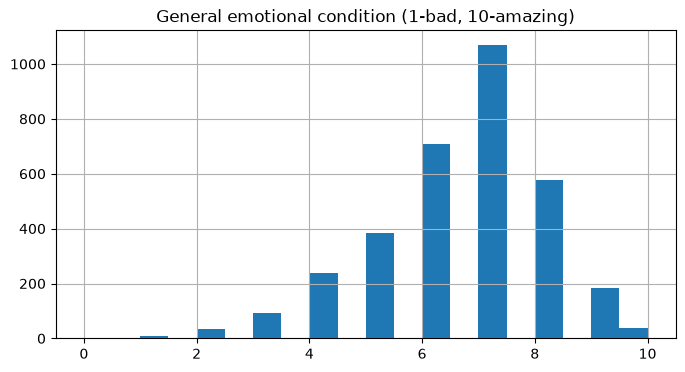

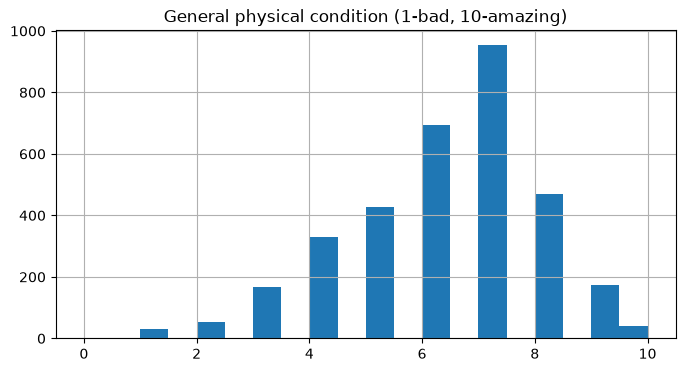

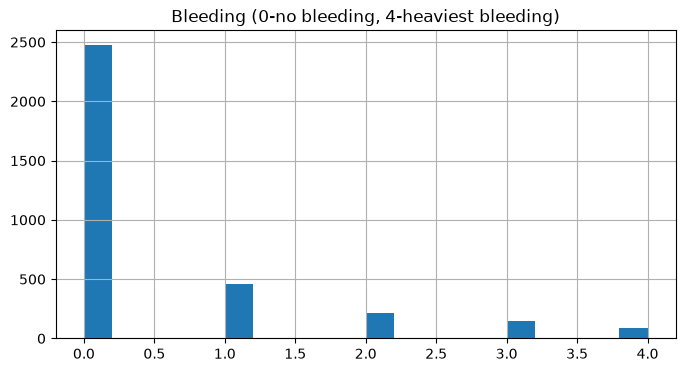

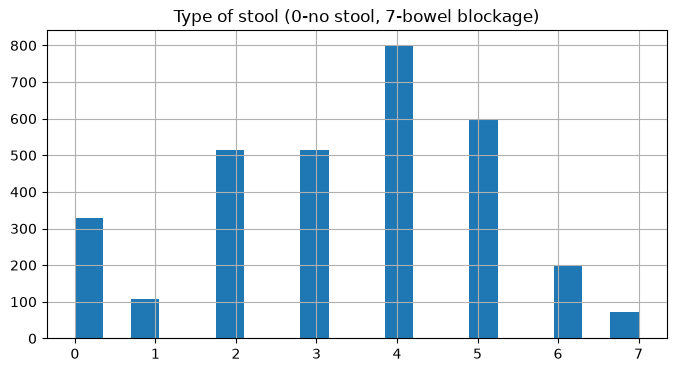

In [24]:
import matplotlib.pyplot as plt

symptoms = [
    "General emotional condition (1-bad, 10-amazing)",
    "General physical condition (1-bad, 10-amazing)",
    "Bleeding (0-no bleeding, 4-heaviest bleeding)",
    "Type of stool (0-no stool, 7-bowel blockage)"
]

for col in symptoms:
    plt.figure(figsize=(8,4))
    all_data[col].hist(bins=20)
    plt.title(col)
    plt.show()

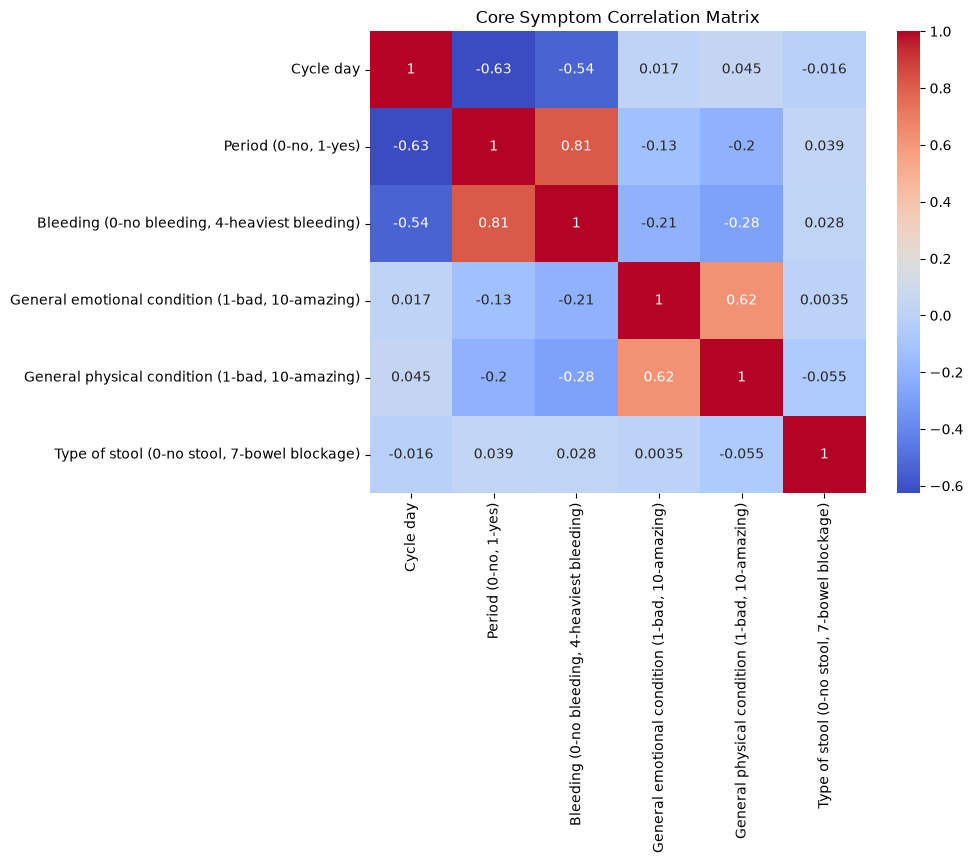

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_core.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Core Symptom Correlation Matrix")
plt.show()